In [31]:
import sys
import numpy as np
import run_ighb

from typing import Dict, List

import matplotlib.pyplot as plt

In [ ]:
bin_counts = range(10, 80, 10)
results = {}

for bin_count in bin_counts:
    print(f"Running with {bin_count} bins")
    sys.argv = ["ighb_notebook", 
                "--dir", "../MultiPL-E/runs/humaneval-all-keep-Qwen2.5_Coder_7B-Instruct-1.0-comp-1/", 
                "--prob-method", "avg_logprob", 
                "--problem", "code-gen", 
                "--split", 
                "--bin-count", str(bin_count),
                "--counter-groups"]

    ighb_results = run_ighb.main(extern=True)
    results[bin_count] = ighb_results

In [ ]:

for k, v in results.items():
    print('scores for', k, 'bins:')
    for name, score in v['scores_calibrated']['Calib'].items():
        if isinstance(score, np.ndarray) and score.shape[0] > 1:
            print(f'{name:10s}: {score}')
        else:
            score = score.item() if hasattr(score, 'item') else score
            print(f'{name:10s}: {score:.3f}')


In [ ]:
#ablation
results_qwen = {
     'compl':       [-0.243406, 0.160069, 0.159981, 0.193489, -0.159551, -0.183953,  0.182182 ],
     'length':      [-0.243406, 0.160069, 0.159981, 0.171875,  -0.222495, -0.122333, 0.155102 ],
     'lang':        [-0.243406, 0.160069, 0.159981, 0.249676 , -0.0897221, -0.243406,  0.285937],
     'length_compl':[-0.243406, 0.160069, 0.159981, 0.196731, -0.166435, -0.122333, 0.195569 ],
     'compl_lang':   [-0.243406, 0.160069, 0.159981, 0.290389, 0.00469423, -0.183953, 0.241252  ],
     'length_lang': [-0.243406, 0.160069, 0.159981, 0.276747, -0.0021903, -0.122333, 0.260551],
     'all':         [-0.243406, 0.160069, 0.159981, 0.297414, 0.0381334, -0.122333, 0.317381]
}

results_r1 = {
    'compl':        [-0.669695, 0.0929692,  0.112199, 0.105417 , -0.294587, -0.447137, 0.140853 ],
     'length':      [-0.669695, 0.0929692, 0.112199, 0.272984, -0.103641, -0.0394072, 0.281807],
     'lang' :       [-0.669695, 0.0929692,  0.112199,  0.320375, -0.020778, -0.669695, 0.39212 ],
     'length_compl':[-0.669695, 0.0929692,  0.112199, 0.279604, -0.0700155, -0.0394072, 0.303114 ],
     'compl_lang' : [-0.669695, 0.0929692,  0.112199,  0.333483,  0.0128477, -0.447137, 0.418732],
     'length_lang': [-0.669695, 0.0929692,  0.112199,  0.442316,  0.302268, -0.0394072, 0.509892 ],
     'all' :        [-0.669695, 0.0929692,  0.112199, 0.446633, 0.311876,  -0.0394072, 0.479345 ]
}

results_gpt_oss = {
     'compl':       [ -0.228201, 0.0973732, 0.0936375, 0.155204, -0.320284, -0.228201,  0.156447] ,
     'length':      [ -0.228201, 0.0973732, 0.0936375, 0.170652, -0.281756 , -0.0381656,  0.170575] ,
     'lang':        [ -0.228201, 0.0973732, 0.0936375, 0.164383, -0.323103,  -0.228201, 0.177932] ,
     'length_compl':[ -0.228201, 0.0973732, 0.0936375, 0.196277 , -0.240409,  -0.0381656, 0.194855],
     'compl_lang':  [ -0.228201, 0.0973732, 0.0936375, 0.219642, -0.153017, -0.228201, 0.230581],
     'length_lang': [ -0.228201, 0.0973732, 0.0936375, 0.226258,  -0.148318,  -0.0381656,  0.236801],
     'all':         [ -0.228201, 0.0973732, 0.0936375, 0.25056, -0.091936 , -0.0381656, 0.249366 ]
}

results_mean = {key:[np.mean((a,b,c)) for a,b,c in zip(results_qwen[key], results_r1[key], results_gpt_oss[key])] for key in results_qwen}

results_std = {key:[np.std((a,b,c)) for a,b,c in zip(results_qwen[key], results_r1[key], results_gpt_oss[key])] for key in results_qwen}






In [82]:

def plot_ablations(results:Dict[str, List[float]], model:str, std:Dict[str, List[float]]=None) -> None:
    
    x = range(0, 7)
    labels = ["Compl.", "Length", "Lang.", "Compl. & Length", "Compl. & Lang.", "Length & Lang.", "All"]
    methods = ['Uncalib', 'Platt', 'HB', 'LINR', 'LOGR', 'IGHB', 'IGLB']
    data = np.array(list(results.values())).T
        
    
    plt.rcParams['axes.labelsize'] = 12
    plt.rcParams['xtick.labelsize'] = 10
    plt.rcParams['ytick.labelsize'] = 10

    fig, ax = plt.subplots(1, figsize=(6, 4))
    if std != None:
        std = np.array(list(std.values())).T
        tmp = list(zip(methods, data, std))
        for label, y, std in reversed(tmp):
            if label in ['Platt', 'HB', 'LINR', 'IGLB']:
                ax.bar(x, y, label = label)

                plt.errorbar(x, y, yerr=std, fmt="o", color="r")
                plt.fill_between(x, y - std, y + std, alpha=0.2)
    else:
        for label, y in zip(methods, data):
            if label in ['Platt', 'HB', 'LINR', 'IGLB']:
                ax.plot(x, y, label = label)

    ax.set_xticks(x, labels)
    ax.tick_params(axis='x', labelrotation=40)
    ax.set(ylabel='Brier Skill Score (BSS)')
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{model}_ablation.pdf")
    plt.show()

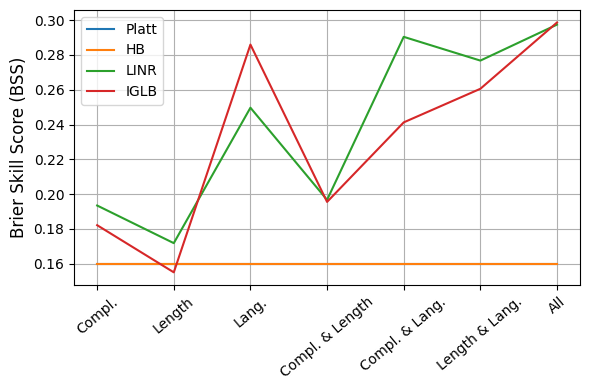

In [78]:
plot_ablations(results_qwen, 'Qwen3')

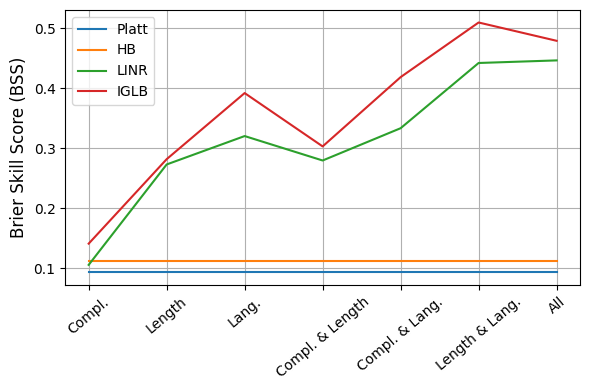

In [79]:
plot_ablations(results_r1, 'DeepSeek R1')

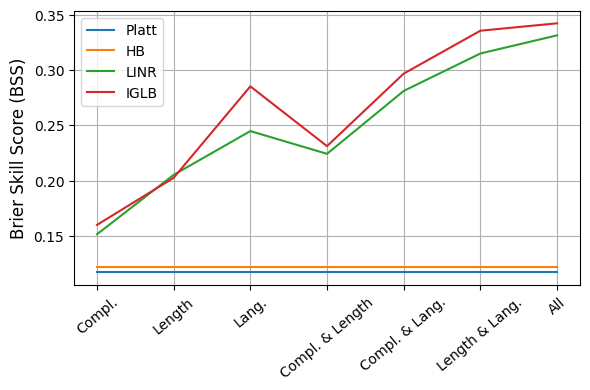

In [80]:
plot_ablations(results_mean, 'mean')

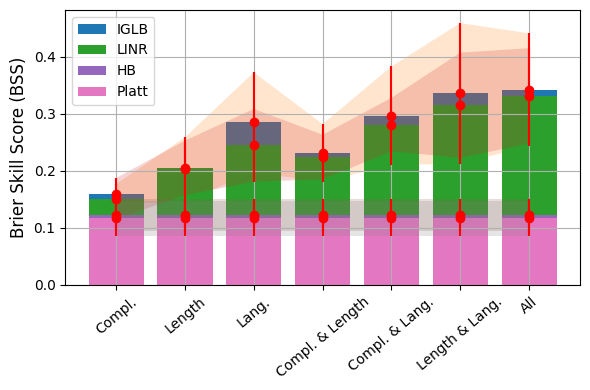

In [83]:
plot_ablations(results_mean, 'mean_std', results_std)